In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Libraries Required

In [49]:
import pandas as pd

# Folder ke path ke aage file ka naam '.csv' ke sath likhein
df = pd.read_csv("/kaggle/input/datasets/muhammadriaze/1st-dataset/Churn_Modelling.csv")

In [50]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [51]:
df.shape

(10000, 14)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [20]:
df.isnull ().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [53]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [54]:
df = df.drop(['RowNumber','CustomerId', 'Surname'], axis = 1)

In [55]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [56]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [57]:
df['Gender'] = df['Gender'].map({'Male' : 0, 'Female' : 1})

In [58]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [ ]:
df = pd.get_dummies(df, columns = ['Geography'], drop_first = True)

In [61]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [62]:
df.dtypes

CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
dtype: object

In [63]:
df.isnull().sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
dtype: int64

In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop("Exited", axis = 1)
y = df["Exited"]
X_scaled = scaler.fit_transform(X)

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [100]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout


In [101]:
model = Sequential()
model.add(Input(shape = (11,)))
model.add(Dense(units = 16, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 16, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1, activation = 'sigmoid'))

In [102]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [103]:
history = model.fit(X_train, y_train, batch_size = 32, epochs =150, validation_data= (X_test, y_test))

Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7795 - loss: 0.5673 - val_accuracy: 0.8080 - val_loss: 0.4460
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7977 - loss: 0.4744 - val_accuracy: 0.8175 - val_loss: 0.4186
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8130 - loss: 0.4432 - val_accuracy: 0.8185 - val_loss: 0.4099
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8025 - loss: 0.4527 - val_accuracy: 0.8250 - val_loss: 0.4002
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8220 - loss: 0.4194 - val_accuracy: 0.8275 - val_loss: 0.3953
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8120 - loss: 0.4362 - val_accuracy: 0.8320 - val_loss: 0.3868
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8150 - loss: 0.4234 - val_accuracy: 0.8395 - val_loss: 0.3811
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8333 - loss: 0.4076 - val_accu

In [104]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Test set par prediction karein
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5) # 0.5 se upar matlab 1 (Exited), niche matlab 0 (Stayed)

# 2. Confusion Matrix banayein
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 3. Accuracy check karein
print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Confusion Matrix:
 [[1555   52]
 [ 220  173]]

Final Test Accuracy: 0.864


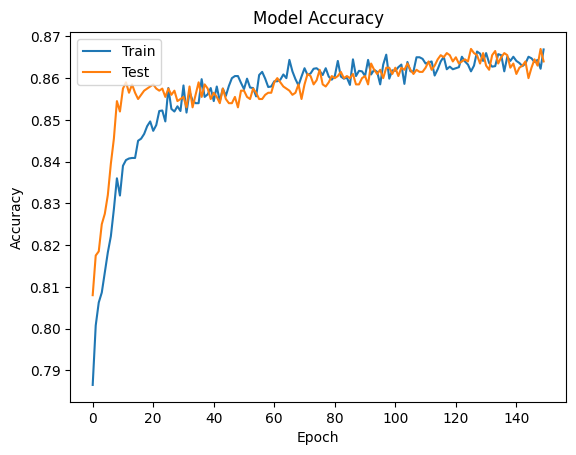

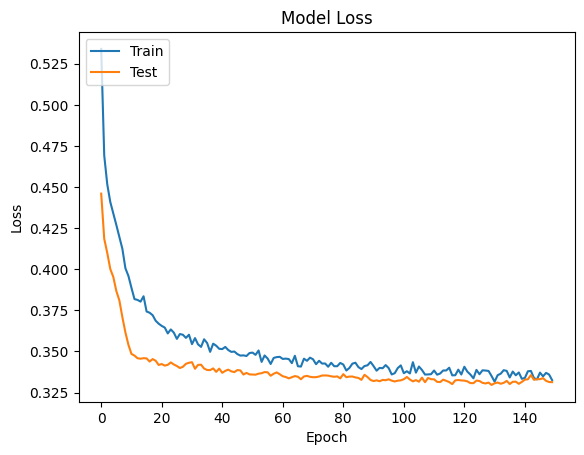

In [105]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Loss Plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [107]:
# Check karein ke aapka scaler kis naam se save hai (scaler ya sc?)
# Farz karein ek naya customer hai:
# CreditScore: 600, Gender: 1 (Male), Age: 40, Tenure: 3, Balance: 60000, 
# NumOfProducts: 2, HasCrCard: 1, IsActiveMember: 1, EstimatedSalary: 50000, 
# Geography_Germany: 1, Geography_Spain: 0

# Warning khatam karne ke liye column names ke sath data dein
import pandas as pd
new_customer_df = pd.DataFrame([[600, 1, 40, 3, 60000, 2, 1, 1, 50000, 1, 0]], columns=X.columns)
new_prediction = model.predict(scaler.transform(new_customer_df))

print(f"Churn Probability: {new_prediction[0][0]:.4f}")

if new_prediction > 0.5:
    print("⚠️ Prediction: Customer is likely to leave the bank!")
else:
    print("✅ Prediction: Customer will stay.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Churn Probability: 0.0405
✅ Prediction: Customer will stay.


In [108]:
# Model ko save karein
model.save('final_bank_churn_model.h5')

# Scaler ko bhi save karna hoga kyunke Frontend mein scaling zaroori hai
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Mubarak ho! Model aur Scaler dono save ho gaye hain. ✅")

Mubarak ho! Model aur Scaler dono save ho gaye hain. ✅
